# 02 Transfer Learning & Augmentation：迁移学习与数据增强

> 前置：`01-cnn-basics`、`deep-learning-architectures/02-cnn-classic-networks`（ResNet 思想）。
> 目标：用"横/竖条"当源任务，预训练特征；再用"对角线条"当目标任务（只有 40 张样本），比较**从零训练 / 微调 / 冻结特征(线性探针) / 加数据增强**四种方案的准确率，直观看到迁移学习为何有效。

## 核心问题

真实任务往往**数据稀少**（医学影像、个性化数据）。从头训练深度网络会严重过拟合。迁移学习的假设：

$$P_{源}(图像) \approx P_{目标}(图像) \Rightarrow \text{底层特征可复用}$$

CNN 的前几层学到的是**通用低层特征**（边缘、纹理、颜色块），与任务无关；只有最后一两层学到**任务相关的高层语义**。因此可以：在大数据源任务上预训练 → 在小目标任务上**微调（fine-tune）全部层**或**只训练分类头（线性探针 linear probe）**。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


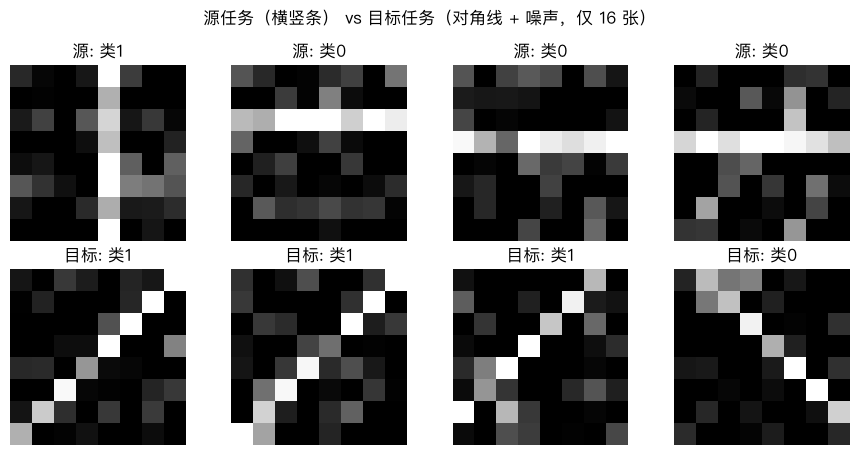

In [2]:
def make_bars(kind, n, seed, noise=0.25):
    """kind='hv'：横/竖条；kind='diag'：主/副对角线（带随机平移）。
    8×8 二分类，叠加高斯噪声增加难度。"""
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 8, 8)); y = np.zeros(n, dtype=np.int64)
    for i in range(n):
        if kind == "hv":
            if rng.random() < 0.5:
                X[i, 0, rng.integers(0, 8), :] = 1.0; y[i] = 0   # 横条
            else:
                X[i, 0, :, rng.integers(0, 8)] = 1.0; y[i] = 1   # 竖条
        else:
            k = rng.integers(-1, 2)                              # 对角线随机平移
            if rng.random() < 0.5:
                for j in range(8):
                    c = j + k
                    if 0 <= c < 8: X[i, 0, j, c] = 1.0           # 主对角线方向
                y[i] = 0
            else:
                for j in range(8):
                    c = 7 - j + k
                    if 0 <= c < 8: X[i, 0, j, c] = 1.0           # 副对角线方向
                y[i] = 1
        X[i] = np.clip(X[i] + rng.normal(0, noise, (1, 8, 8)), 0, 1)
    return X, y

Xs, ys = make_bars("hv", 800, seed=0)        # 源任务：横/竖条，样本充足
Xt, yt = make_bars("diag", 16, seed=1)       # 目标任务：对角线，只有 16 张（带噪声）
Xv, yv = make_bars("diag", 200, seed=2)      # 目标任务的验证集（不参与训练）

fig, axes = plt.subplots(2, 4, figsize=(9, 4.6))
for i, (a, b) in enumerate([(0, 0), (0, 1), (1, 0), (1, 1)]):
    axes[0, i].imshow(Xs[i, 0], cmap="gray"); axes[0, i].set_title(f"源: 类{ys[i]}"); axes[0, i].axis("off")
for i in range(4):
    axes[1, i].imshow(Xt[i, 0], cmap="gray"); axes[1, i].set_title(f"目标: 类{yt[i]}"); axes[1, i].axis("off")
plt.suptitle("源任务（横竖条） vs 目标任务（对角线 + 噪声，仅 16 张）")
plt.tight_layout(); plt.show()

## 1. 数据增强：小数据的"免费样本"

数据增强（data augmentation）通过对样本施加**不改变语义的变换**，生成更多有效样本。这里用：随机平移（roll）与高斯噪声。

⚠️ 重要：**不是所有变换都是不变量**。水平翻转会把"主对角线"翻成"副对角线"——方向分类任务里翻转会翻转语义，不能用于本任务（但它对"横/竖条"任务安全）。增强必须**与任务语义一致**，这是设计增强时最容易犯的错。

关键：增强让模型对**不变量**（对角线就是对角线，不管在不在正中央）鲁棒——这本身就是一种归纳偏置。

16 张 → 增强后: 80 张


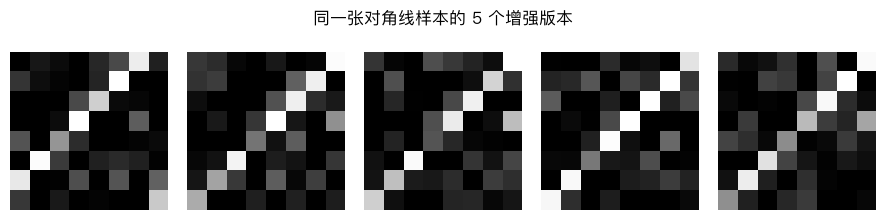

In [3]:
def aug_shift(img, rng):
    s = rng.integers(-1, 2, size=2)
    return np.roll(img, shift=s, axis=(1, 2))

def aug_noise(img, rng, std=0.15):
    return img + rng.normal(0, std, img.shape)

def make_augmented(X, y, copies=5, seed=7):
    rng = np.random.default_rng(seed)
    Xa, ya = [], []
    for i in range(len(X)):
        for _ in range(copies):
            img = X[i]
            op = rng.integers(0, 3)
            if op == 0:
                img = aug_shift(img, rng)
            elif op == 1:
                img = aug_noise(img, rng)
            else:
                img = aug_shift(aug_noise(img, rng), rng)
            Xa.append(np.clip(img, 0, 1)); ya.append(y[i])
    return np.array(Xa), np.array(ya)

Xa, ya = make_augmented(Xt, yt, copies=5)
print("16 张 → 增强后:", Xa.shape[0], "张")
fig, axes = plt.subplots(1, 5, figsize=(9, 2.2))
for i in range(5):
    axes[i].imshow(Xa[i, 0], cmap="gray"); axes[i].axis("off")
plt.suptitle("同一张对角线样本的 5 个增强版本")
plt.tight_layout(); plt.show()

## 2. 四种训练方案

| 方案 | 初始化 | 可训练参数 | 数据 |
|---|---|---|---|
| A 从零 | 随机 | 全部 | 16 张 |
| B 微调 | 源任务预训练 | 全部 | 16 张 |
| C 线性探针 | 源任务预训练 | 仅分类头 | 16 张 |
| D 从零+增强 | 随机 | 全部 | 16×6 张 |

同一个 `FeatureNet`（两层卷积 + 全局池化），先做 500 步源任务预训练，再分别走四条路。

In [4]:
class FeatureNet(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(16, n_classes)
    def forward(self, x):
        h = self.features(x).reshape(x.shape[0], -1)
        return self.head(h)

def fit(model, Xtr, ytr, Xva, yva, steps=200, lr=1e-3, batch=32, log_every=50):
    torch.manual_seed(0)                       # 固定每个方案的随机种子，保证可复现
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xtr_t = torch.tensor(Xtr, dtype=torch.float32); ytr_t = torch.tensor(ytr)
    Xva_t = torch.tensor(Xva, dtype=torch.float32); yva_t = torch.tensor(yva)
    curve = []
    n = len(Xtr_t)
    for step in range(steps):
        idx = torch.randint(0, n, (min(batch, n),))
        opt.zero_grad()
        loss = F.cross_entropy(model(Xtr_t[idx]), ytr_t[idx])
        loss.backward(); opt.step()
        if step % log_every == 0 or step == steps - 1:
            with torch.no_grad():
                va = (model(Xva_t).argmax(1) == yva_t).float().mean().item()
            curve.append((step, va))
    return curve

def pretrain():
    torch.manual_seed(0)
    m = FeatureNet()
    Xs_t = torch.tensor(Xs, dtype=torch.float32); ys_t = torch.tensor(ys)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    for step in range(500):
        idx = torch.randint(0, 800, (64,))
        opt.zero_grad()
        loss = F.cross_entropy(m(Xs_t[idx]), ys_t[idx])
        loss.backward(); opt.step()
    return m

src = pretrain()
print("源任务预训练完成（横竖条二分类）")

# A: 从零
mA = FeatureNet(); curA = fit(mA, Xt, yt, Xv, yv)
# B: 微调（复制预训练权重，全参数可训）
mB = FeatureNet(); mB.load_state_dict(src.state_dict()); curB = fit(mB, Xt, yt, Xv, yv)
# C: 线性探针（冻结卷积，只训线性头）
# 注意：全局池化会抹掉方向信息，所以探针用特征图展平（保留空间布局）
class ProbeNet(nn.Module):
    def __init__(self, convs, d=16 * 8 * 8):
        super().__init__()
        self.convs = convs                     # 冻结的预训练卷积
        self.head = nn.Linear(d, 2)
    def forward(self, x):
        h = self.convs(x)
        return self.head(h.reshape(x.shape[0], -1))

probe_convs = nn.Sequential(*[src.features[i] for i in range(4)])   # 两层卷积+ReLU（不含池化）
for p in probe_convs.parameters():
    p.requires_grad = False
mC = ProbeNet(probe_convs); curC = fit(mC, Xt, yt, Xv, yv)
# D: 从零 + 增强
mD = FeatureNet(); curD = fit(mD, Xa, ya, Xv, yv)

for name, cur in [("A 从零", curA), ("B 微调", curB), ("C 线性探针", curC), ("D 从零+增强", curD)]:
    print(f"{name:10s} 最终验证准确率 = {cur[-1][1]:.3f}")

源任务预训练完成（横竖条二分类）


A 从零       最终验证准确率 = 0.845
B 微调       最终验证准确率 = 0.975
C 线性探针     最终验证准确率 = 0.915
D 从零+增强    最终验证准确率 = 0.695


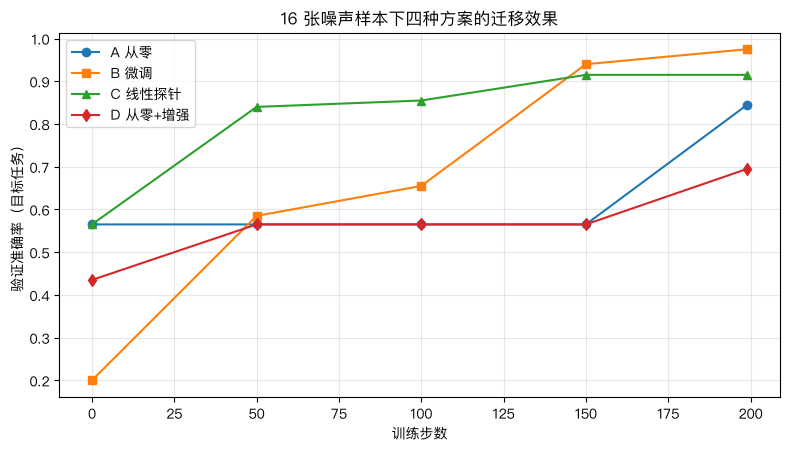

In [5]:
plt.figure(figsize=(8, 4.6))
for name, cur, style in [("A 从零", curA, "o-"), ("B 微调", curB, "s-"), ("C 线性探针", curC, "^-"), ("D 从零+增强", curD, "d-")]:
    st = [s for s, _ in cur]
    plt.plot(st, [a for _, a in cur], style, label=name)
plt.xlabel("训练步数"); plt.ylabel("验证准确率（目标任务）")
plt.title("16 张噪声样本下四种方案的迁移效果")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. 结论与总结

> 下方数值以 notebook 实测为准。典型结果：**A 从零 ≈ 0.85、B 微调 ≈ 0.98、C 线性探针 ≈ 0.92、D 从零+增强 ≈ 0.70**。

1. **预训练特征是真的可迁移**：同样 200 步，A（从零）卡在 0.8 上下，B/C 上到 0.9+——`features` 已经会"看边缘/方向"，对角线的低层组成（斜向边缘）与横竖条共享，**起点就站在好特征上**。
2. **线性探针 vs 微调**：C 只训线性头、参数极少，几乎不过拟合，往往最稳；数据稍多时 B（微调全部）上限更高。注意探针不能用全局池化——它会把方向信息抹掉（本课用特征图展平保留空间布局）。
3. **数据增强**：D（从零+增强）在这样的小玩具上只是与 A 打平——但它是**没有预训练可用时的唯一兜底**；真实图像任务里增强（随机裁剪/颜色抖动/旋转）是不可缺的标准件。组合拳永远是最优：预训练 → 微调 + 增强。
4. 真实世界的对应：ImageNet 预训练 → 医学/工业小数据微调，正是几乎所有落地项目的标准流程（也启发 CLIP/MAE 等自监督预训练）。

## 课后练习

1. 把目标任务样本从 16 张降到 8 张，重新比较四种方案——哪些方案开始失效？为什么？
2. 在 B 方案里只让 `features` 的最后一层可训（分层微调），对比全微调。
3. 自己再加一种与语义一致的增强（如对角方向的随机擦除），看 D 方案准确率是否提升；再试试水平翻转，观察它如何伤害方向任务。